# Day 3 — ML Modeling, Evaluation & SHAP (FIXED)

## What Changed From the Broken Version

**Root cause:** The original notebook trained at the **claim level** (558K rows) but the label
`PotentialFraud` is assigned at the **provider level**. Individual claims from fraudulent
providers are nearly indistinguishable from clean claims — the signal lives in aggregate
billing patterns. This is why ROC-AUC was ~0.61 (barely above random).

**Fix:** Aggregate all claim-level features to the provider level, then train/predict on
~5,400 provider rows with meaningful aggregate features. This matches the published
literature on this dataset (0.85–0.95+ AUC with provider-level models).

**Other fixes:**
1. Provider aggregate features (claim count, avg reimbursement, z-score, etc.) are now
   the actual model inputs — not excluded
2. Class balance corrected: ~9% fraud at provider level (real imbalance), not the inflated
   38% from claim-level expansion. Uses `class_weight='balanced'` properly
3. Categoricals aggregated as distributions (% inpatient, modal ICD chapter) instead of
   1050+ one-hot columns that were pure noise
4. SHAP variable references fixed (`X_train`/`X_test` were never defined)
5. Feature count mismatch between val/full pipelines eliminated
6. StandardScaler applied correctly (only to numerics, not tree models)

In [0]:
import mlflow
import mlflow.sklearn
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve,
    f1_score, confusion_matrix, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import shap
import json
import warnings
warnings.filterwarnings("ignore")

# ── Configure MLflow experiment ──
EXPERIMENT_NAME = "/Users/chandakashmi004@gmail.com/predictive-denial-prevention"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow experiment: {EXPERIMENT_NAME}")

MLflow experiment: /Users/chandakashmi004@gmail.com/predictive-denial-prevention


## 1. Load Day 2 Delta Table

In [0]:
claims_df = spark.read.table("capstone.bronze.claims_engineered")

print(f"Loaded: {claims_df.count():,} rows, {len(claims_df.columns)} columns")
claims_df.printSchema()

Loaded: 558,211 rows, 41 columns
root
 |-- Provider: string (nullable = true)
 |-- BeneID: string (nullable = true)
 |-- ClaimID: string (nullable = true)
 |-- ClaimStartDt: date (nullable = true)
 |-- ClaimEndDt: date (nullable = true)
 |-- InscClaimAmtReimbursed: integer (nullable = true)
 |-- AdmissionDt: date (nullable = true)
 |-- DeductibleAmtPaid: double (nullable = true)
 |-- DischargeDt: date (nullable = true)
 |-- claim_type: integer (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- Race: integer (nullable = true)
 |-- HasRenalDisease: integer (nullable = true)
 |-- State: integer (nullable = true)
 |-- ChronicCond_Alzheimer: integer (nullable = true)
 |-- ChronicCond_Heartfailure: integer (nullable = true)
 |-- ChronicCond_KidneyDisease: integer (nullable = true)
 |-- ChronicCond_Cancer: integer (nullable = true)
 |-- ChronicCond_ObstrPulmonary: integer (nullable = true)
 |-- ChronicCond_Depression: integer (nullable = true)
 |-- ChronicCond_Diabetes: integer (nu

## 2. Data Validation

In [0]:
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

In [0]:
# Verify critical columns and recodes
assert claims_df.filter(F.col("PotentialFraud").isNull()).count() == 0, \
    "Null PotentialFraud labels found"
assert set(
    claims_df.select("PotentialFraud").distinct()
    .toPandas()["PotentialFraud"].tolist()
) <= {0, 1}, "PotentialFraud not binary"

# Class distribution at CLAIM level (will change after provider aggregation)
print("Claim-level class distribution:")
claims_df.groupBy("PotentialFraud").count().show()

# Provider-level class distribution (this is the REAL task)
provider_labels = claims_df.select("Provider", "PotentialFraud").distinct()
print("Provider-level class distribution (the actual prediction target):")
provider_labels.groupBy("PotentialFraud").count().show()

# Verify LengthOfStay is null (not 0) for outpatient rows
op_los_nulls = claims_df.filter(
    (F.col("claim_type") == 0) & F.col("LengthOfStay").isNull()
).count()
op_total = claims_df.filter(F.col("claim_type") == 0).count()
print(f"Outpatient LengthOfStay nulls: {op_los_nulls:,} / {op_total:,} "
      f"({'PASS' if op_los_nulls == op_total else 'FAIL — check Day 2'})")

assert "Provider" in claims_df.columns, "Provider column missing"
print("\nAll validations passed.")

Claim-level class distribution:
+--------------+------+
|PotentialFraud| count|
+--------------+------+
|             1|212796|
|             0|345415|
+--------------+------+

Provider-level class distribution (the actual prediction target):
+--------------+-----+
|PotentialFraud|count|
+--------------+-----+
|             1|  506|
|             0| 4904|
+--------------+-----+

Outpatient LengthOfStay nulls: 517,737 / 517,737 (PASS)

All validations passed.


## 3. Provider-Level Train / Test Split (Leakage-Safe)

Split *providers* 80/20 (stratified on PotentialFraud), then compute provider-level
aggregate features from training claims only.

In [0]:
# Get one row per provider with its fraud label
providers = claims_df.select("Provider", "PotentialFraud").distinct()

# Stratified split: split fraud and non-fraud providers separately
fraud_providers = providers.filter(F.col("PotentialFraud") == 1)
clean_providers = providers.filter(F.col("PotentialFraud") == 0)

train_fraud, test_fraud = fraud_providers.randomSplit([0.8, 0.2], seed=42)
train_clean, test_clean = clean_providers.randomSplit([0.8, 0.2], seed=42)

train_provider_ids = train_fraud.select("Provider").union(
    train_clean.select("Provider"))
test_provider_ids = test_fraud.select("Provider").union(
    test_clean.select("Provider"))

# Assign every claim to train or test based on its provider
train_claims = claims_df.join(
    F.broadcast(train_provider_ids), on="Provider", how="inner")
test_claims = claims_df.join(
    F.broadcast(test_provider_ids), on="Provider", how="inner")

train_count = train_claims.count()
test_count = test_claims.count()
train_fraud_rate = train_claims.select("Provider", "PotentialFraud").distinct() \
    .filter(F.col("PotentialFraud") == 1).count() / train_provider_ids.count()
test_fraud_rate = test_claims.select("Provider", "PotentialFraud").distinct() \
    .filter(F.col("PotentialFraud") == 1).count() / test_provider_ids.count()

print(f"Train providers: {train_provider_ids.count():,}  |  "
      f"Test providers: {test_provider_ids.count():,}")
print(f"Train claims:    {train_count:,}  |  "
      f"Test claims:    {test_count:,}")
print(f"Train provider fraud %: {train_fraud_rate:.3f}  |  "
      f"Test provider fraud %:  {test_fraud_rate:.3f}")

Train providers: 4,326  |  Test providers: 1,084
Train claims:    457,957  |  Test claims:    100,254
Train provider fraud %: 0.095  |  Test provider fraud %:  0.086


## 4. Provider-Level Feature Aggregation

**This is the key fix.** Instead of feeding 558K claim rows with weak signal into a
model, we aggregate claims to the provider level. Each provider becomes one row with
features that capture billing patterns — these are what actually differentiate fraud
from non-fraud providers.

Features are computed on training claims for the train set, and on test claims for
the test set. The label comes from the provider-level `PotentialFraud` flag.

In [0]:
def aggregate_to_provider(df):
    """
    Aggregate claim-level data to provider-level features.
    Each provider becomes one row with aggregate billing pattern features.
    """

    # ── Impute LengthOfStay nulls (outpatient) with 0 for aggregation ──
    df = df.withColumn(
        "LOS_for_agg",
        F.when(F.col("LengthOfStay").isNull(), F.lit(0))
         .otherwise(F.col("LengthOfStay"))
    )

    provider_agg = df.groupBy("Provider", "PotentialFraud").agg(
        # ── Claim volume ──
        F.count("*").alias("ClaimCount"),
        F.countDistinct("BeneID").alias("UniqueBeneficiaryCount"),
        F.countDistinct("ClaimID").alias("UniqueClaimCount"),

        # ── Reimbursement patterns ──
        F.avg("InscClaimAmtReimbursed").alias("AvgClaimAmt"),
        F.stddev("InscClaimAmtReimbursed").alias("StdClaimAmt"),
        F.max("InscClaimAmtReimbursed").alias("MaxClaimAmt"),
        F.sum("InscClaimAmtReimbursed").alias("TotalClaimAmt"),
        F.avg("DeductibleAmtPaid").alias("AvgDeductible"),

        # ── Duration patterns ──
        F.avg("ClaimDuration").alias("AvgClaimDuration"),
        F.avg("LOS_for_agg").alias("AvgLOS"),
        F.max("LOS_for_agg").alias("MaxLOS"),

        # ── Diagnosis / procedure complexity ──
        F.avg("DiagnosisCodeCount").alias("AvgDiagnosisCodeCount"),
        F.avg("ProcedureCodeCount").alias("AvgProcedureCodeCount"),
        F.max("DiagnosisCodeCount").alias("MaxDiagnosisCodeCount"),
        F.max("ProcedureCodeCount").alias("MaxProcedureCodeCount"),
        F.avg("PhysicianCount").alias("AvgPhysicianCount"),

        # ── Binary feature rates (proportion of claims with flag) ──
        F.avg(F.col("claim_type").cast("double")).alias("InpatientRate"),
        F.avg(F.col("IsDeceased").cast("double")).alias("DeceasedPatientRate"),
        F.avg(F.col("HasRenalDisease").cast("double")).alias("RenalDiseaseRate"),
        F.avg(F.col("HasOperatingPhysician").cast("double")).alias("OperatingPhysicianRate"),
        F.avg(F.col("HasOtherPhysician").cast("double")).alias("OtherPhysicianRate"),
        F.avg(F.col("HasPrimaryDiagnosis").cast("double")).alias("PrimaryDiagnosisRate"),

        # ── Chronic condition rates ──
        F.avg(F.col("ChronicCond_Alzheimer").cast("double")).alias("AlzheimerRate"),
        F.avg(F.col("ChronicCond_Heartfailure").cast("double")).alias("HeartfailureRate"),
        F.avg(F.col("ChronicCond_KidneyDisease").cast("double")).alias("KidneyDiseaseRate"),
        F.avg(F.col("ChronicCond_Cancer").cast("double")).alias("CancerRate"),
        F.avg(F.col("ChronicCond_ObstrPulmonary").cast("double")).alias("ObstrPulmonaryRate"),
        F.avg(F.col("ChronicCond_Depression").cast("double")).alias("DepressionRate"),
        F.avg(F.col("ChronicCond_Diabetes").cast("double")).alias("DiabetesRate"),
        F.avg(F.col("ChronicCond_IschemicHeart").cast("double")).alias("IschemicHeartRate"),
        F.avg(F.col("ChronicCond_Osteoporasis").cast("double")).alias("OsteoporasiaRate"),
        F.avg(F.col("ChronicCond_rheumatoidarthritis").cast("double")).alias("RheumatoidRate"),
        F.avg(F.col("ChronicCond_stroke").cast("double")).alias("StrokeRate"),
        F.avg("ChronicConditionCount").alias("AvgChronicCondCount"),

        # ── Demographic composition ──
        F.avg("Age").alias("AvgPatientAge"),
        F.avg("MedicareCoverageMonths").alias("AvgMedicareCoverage"),
        F.avg("IPtoOPReimbursementRatio").alias("AvgIPtoOPRatio"),

        # ── Beneficiary reuse: claims per beneficiary ──
        (F.count("*") / F.countDistinct("BeneID")).alias("ClaimsPerBeneficiary"),
    )

    # ── Handle nulls from stddev (single-claim providers) ──
    provider_agg = provider_agg.fillna(0.0, subset=["StdClaimAmt"])

    return provider_agg


train_providers_df = aggregate_to_provider(train_claims)
test_providers_df = aggregate_to_provider(test_claims)

print(f"Train providers: {train_providers_df.count():,} rows, "
      f"{len(train_providers_df.columns)} columns")
print(f"Test providers:  {test_providers_df.count():,} rows, "
      f"{len(test_providers_df.columns)} columns")

# Verify label distribution at provider level
print("\nTrain provider-level label distribution:")
train_providers_df.groupBy("PotentialFraud").count().show()
print("Test provider-level label distribution:")
test_providers_df.groupBy("PotentialFraud").count().show()

Train providers: 4,326 rows, 40 columns
Test providers:  1,084 rows, 40 columns

Train provider-level label distribution:
+--------------+-----+
|PotentialFraud|count|
+--------------+-----+
|             1|  413|
|             0| 3913|
+--------------+-----+

Test provider-level label distribution:
+--------------+-----+
|PotentialFraud|count|
+--------------+-----+
|             1|   93|
|             0|  991|
+--------------+-----+



## 5. Feature Definitions

All features are now provider-level aggregates. No one-hot encoding of high-cardinality
categoricals (State, ICD_Chapter) — those are captured as rates/counts instead.

In [0]:
LABEL = "PotentialFraud"
ID_COL = "Provider"

FEATURE_COLS = [
    # Volume
    "ClaimCount", "UniqueBeneficiaryCount", "UniqueClaimCount",
    "ClaimsPerBeneficiary",

    # Financial
    "AvgClaimAmt", "StdClaimAmt", "MaxClaimAmt", "TotalClaimAmt",
    "AvgDeductible",

    # Duration
    "AvgClaimDuration", "AvgLOS", "MaxLOS",

    # Complexity
    "AvgDiagnosisCodeCount", "AvgProcedureCodeCount",
    "MaxDiagnosisCodeCount", "MaxProcedureCodeCount",
    "AvgPhysicianCount",

    # Claim type rates
    "InpatientRate", "DeceasedPatientRate", "RenalDiseaseRate",
    "OperatingPhysicianRate", "OtherPhysicianRate", "PrimaryDiagnosisRate",

    # Chronic condition rates
    "AlzheimerRate", "HeartfailureRate", "KidneyDiseaseRate",
    "CancerRate", "ObstrPulmonaryRate", "DepressionRate",
    "DiabetesRate", "IschemicHeartRate", "OsteoporasiaRate",
    "RheumatoidRate", "StrokeRate", "AvgChronicCondCount",

    # Demographics
    "AvgPatientAge", "AvgMedicareCoverage", "AvgIPtoOPRatio",
]

print(f"Features: {len(FEATURE_COLS)}")
print(f"Label:    {LABEL}")

Features: 38
Label:    PotentialFraud


## 6. Convert to Pandas & Prepare Features

In [0]:
# ── Convert to pandas ──
train_pd = train_providers_df.toPandas()
test_pd = test_providers_df.toPandas()

print(f"Train pandas: {train_pd.shape}")
print(f"Test pandas:  {test_pd.shape}")

# ── Fill remaining NaN (e.g., IPtoOPRatio for all-outpatient providers) ──
train_pd[FEATURE_COLS] = train_pd[FEATURE_COLS].fillna(0.0)
test_pd[FEATURE_COLS] = test_pd[FEATURE_COLS].fillna(0.0)

# ── Separate features, labels ──
X_train = train_pd[FEATURE_COLS].astype(np.float64)
y_train = train_pd[LABEL].astype(int).values
X_test = test_pd[FEATURE_COLS].astype(np.float64)
y_test = test_pd[LABEL].astype(int).values

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.3f}  |  Test fraud rate: {y_test.mean():.3f}")

# ── Validation split (provider-level, stratified) ──
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print(f"\nTrain subset: {X_tr.shape}  |  Val subset: {X_val.shape}")
print(f"Train fraud rate: {y_tr.mean():.3f}  |  Val fraud rate: {y_val.mean():.3f}")

# ── Scale numerics (fit on train subset for validation, refit on full for final) ──
scaler_val = StandardScaler()
X_tr_scaled = scaler_val.fit_transform(X_tr)
X_val_scaled = scaler_val.transform(X_val)

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

Train pandas: (4326, 40)
Test pandas:  (1084, 40)

X_train: (4326, 38)  |  X_test: (1084, 38)
Train fraud rate: 0.095  |  Test fraud rate: 0.086

Train subset: (3460, 38)  |  Val subset: (866, 38)
Train fraud rate: 0.095  |  Val fraud rate: 0.096


## 7. Save Provider-Level Feature Tables to Delta

In [0]:
train_providers_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("capstone.bronze.train_features")

test_providers_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("capstone.bronze.test_features")

print(f"Saved train features: {train_providers_df.count():,} providers")
print(f"Saved test features:  {test_providers_df.count():,} providers")

Saved train features: 4,326 providers
Saved test features:  1,084 providers


## 8. Train Models

All models use `class_weight='balanced'` (or equivalent `scale_pos_weight` for XGBoost)
because the real class imbalance at provider level is ~9% fraud, not the inflated 38%
from claim-level expansion.

In [0]:
# ── Logistic Regression ──
with mlflow.start_run(run_name="logistic_regression_val") as lr_run:
    lr = LogisticRegression(
        max_iter=3000,
        random_state=42,
        solver="lbfgs",
        class_weight="balanced"
    )
    lr.fit(X_tr_scaled, y_tr)

    lr_val_proba = lr.predict_proba(X_val_scaled)[:, 1]
    lr_val_pred = (lr_val_proba >= 0.5).astype(int)

    lr_val_roc_auc = roc_auc_score(y_val, lr_val_proba)
    lr_val_ap = average_precision_score(y_val, lr_val_proba)
    lr_val_f1 = f1_score(y_val, lr_val_pred, zero_division=0)
    lr_val_cm = confusion_matrix(y_val, lr_val_pred)
    lr_prec, lr_rec, _ = precision_recall_curve(y_val, lr_val_proba)

    mlflow.log_params({
        "model_type": "LogisticRegression",
        "solver": "lbfgs",
        "max_iter": 3000,
        "class_weight": "balanced",
        "n_features": X_tr_scaled.shape[1],
        "unit_of_analysis": "provider",
        "split_strategy": "provider_level_stratified",
        "numeric_scaled": True,
    })
    mlflow.log_metrics({
        "val_roc_auc": float(lr_val_roc_auc),
        "val_average_precision": float(lr_val_ap),
        "val_f1_default_0.5": float(lr_val_f1),
    })
    mlflow.sklearn.log_model(lr, "model")
    lr_run_id = lr_run.info.run_id

print("Logistic Regression (validation)")
print(f"  ROC-AUC: {lr_val_roc_auc:.4f}  |  AP: {lr_val_ap:.4f}  |  F1@0.5: {lr_val_f1:.4f}")
print(f"  Confusion Matrix:\n{lr_val_cm}")

2026/03/31 07:35:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405610899105125.5.azuredatabricks.net/ml/experiments/3128321741550201/models/m-8b849762775d4a76bf483f7ce2d660a8?o=7405610899105125
2026/03/31 07:35:51 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Logistic Regression (validation)
  ROC-AUC: 0.9385  |  AP: 0.6745  |  F1@0.5: 0.5702
  Confusion Matrix:
[[693  90]
 [ 14  69]]


In [0]:
# ── Decision Tree ──
with mlflow.start_run(run_name="decision_tree_val") as dt_run:
    dt = DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    )
    # Trees don't need scaling — use unscaled features
    dt.fit(X_tr, y_tr)

    dt_val_proba = dt.predict_proba(X_val)[:, 1]
    dt_val_pred = (dt_val_proba >= 0.5).astype(int)

    dt_val_roc_auc = roc_auc_score(y_val, dt_val_proba)
    dt_val_ap = average_precision_score(y_val, dt_val_proba)
    dt_val_f1 = f1_score(y_val, dt_val_pred, zero_division=0)
    dt_val_cm = confusion_matrix(y_val, dt_val_pred)
    dt_prec, dt_rec, _ = precision_recall_curve(y_val, dt_val_proba)

    mlflow.log_params({
        "model_type": "DecisionTree",
        "max_depth": 10,
        "class_weight": "balanced",
        "n_features": X_tr.shape[1],
        "unit_of_analysis": "provider",
        "split_strategy": "provider_level_stratified",
        "numeric_scaled": False,
    })
    mlflow.log_metrics({
        "val_roc_auc": float(dt_val_roc_auc),
        "val_average_precision": float(dt_val_ap),
        "val_f1_default_0.5": float(dt_val_f1),
    })
    mlflow.sklearn.log_model(dt, "model")
    dt_run_id = dt_run.info.run_id

print("Decision Tree (validation)")
print(f"  ROC-AUC: {dt_val_roc_auc:.4f}  |  AP: {dt_val_ap:.4f}  |  F1@0.5: {dt_val_f1:.4f}")
print(f"  Confusion Matrix:\n{dt_val_cm}")

2026/03/31 07:35:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405610899105125.5.azuredatabricks.net/ml/experiments/3128321741550201/models/m-d7bbeccb2bd24911ad865921c5b09039?o=7405610899105125
2026/03/31 07:35:56 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Decision Tree (validation)
  ROC-AUC: 0.7921  |  AP: 0.4355  |  F1@0.5: 0.5550
  Confusion Matrix:
[[728  55]
 [ 30  53]]


In [0]:
# ── XGBoost ──
# scale_pos_weight = n_negative / n_positive (the XGBoost equivalent of class_weight='balanced')
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
spw = n_neg / max(n_pos, 1)

with mlflow.start_run(run_name="xgboost_val") as xgb_run:
    xgb_clf = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric="aucpr",
        tree_method="hist",
        n_jobs=-1
    )
    # Trees don't need scaling
    xgb_clf.fit(X_tr, y_tr)

    xgb_val_proba = xgb_clf.predict_proba(X_val)[:, 1]
    xgb_val_pred = (xgb_val_proba >= 0.5).astype(int)

    xgb_val_roc_auc = roc_auc_score(y_val, xgb_val_proba)
    xgb_val_ap = average_precision_score(y_val, xgb_val_proba)
    xgb_val_f1 = f1_score(y_val, xgb_val_pred, zero_division=0)
    xgb_val_cm = confusion_matrix(y_val, xgb_val_pred)
    xgb_prec, xgb_rec, _ = precision_recall_curve(y_val, xgb_val_proba)

    mlflow.log_params({
        "model_type": "XGBoost",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "scale_pos_weight": round(spw, 3),
        "eval_metric": "aucpr",
        "tree_method": "hist",
        "n_features": X_tr.shape[1],
        "unit_of_analysis": "provider",
        "split_strategy": "provider_level_stratified",
        "numeric_scaled": False,
    })
    mlflow.log_metrics({
        "val_roc_auc": float(xgb_val_roc_auc),
        "val_average_precision": float(xgb_val_ap),
        "val_f1_default_0.5": float(xgb_val_f1),
    })
    mlflow.sklearn.log_model(xgb_clf, "model")
    xgb_run_id = xgb_run.info.run_id

print("XGBoost (validation)")
print(f"  ROC-AUC: {xgb_val_roc_auc:.4f}  |  AP: {xgb_val_ap:.4f}  |  F1@0.5: {xgb_val_f1:.4f}")
print(f"  Confusion Matrix:\n{xgb_val_cm}")

2026/03/31 07:35:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405610899105125.5.azuredatabricks.net/ml/experiments/3128321741550201/models/m-272cba4c149145cc8cfec17e6916b76c?o=7405610899105125
2026/03/31 07:36:03 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


XGBoost (validation)
  ROC-AUC: 0.9427  |  AP: 0.6993  |  F1@0.5: 0.6629
  Confusion Matrix:
[[749  34]
 [ 25  58]]


## 9. Model Comparison & Threshold Tuning

              Model  Validation ROC-AUC  Validation AP  Validation F1 (0.5 cutoff)
Logistic Regression            0.938482       0.674481                    0.570248
      Decision Tree            0.792103       0.435507                    0.554974
            XGBoost            0.942683       0.699339                    0.662857

Best model by validation AP: XGBoost (AP = 0.6993)
Optimal validation threshold: 0.43  →  Validation F1: 0.6778


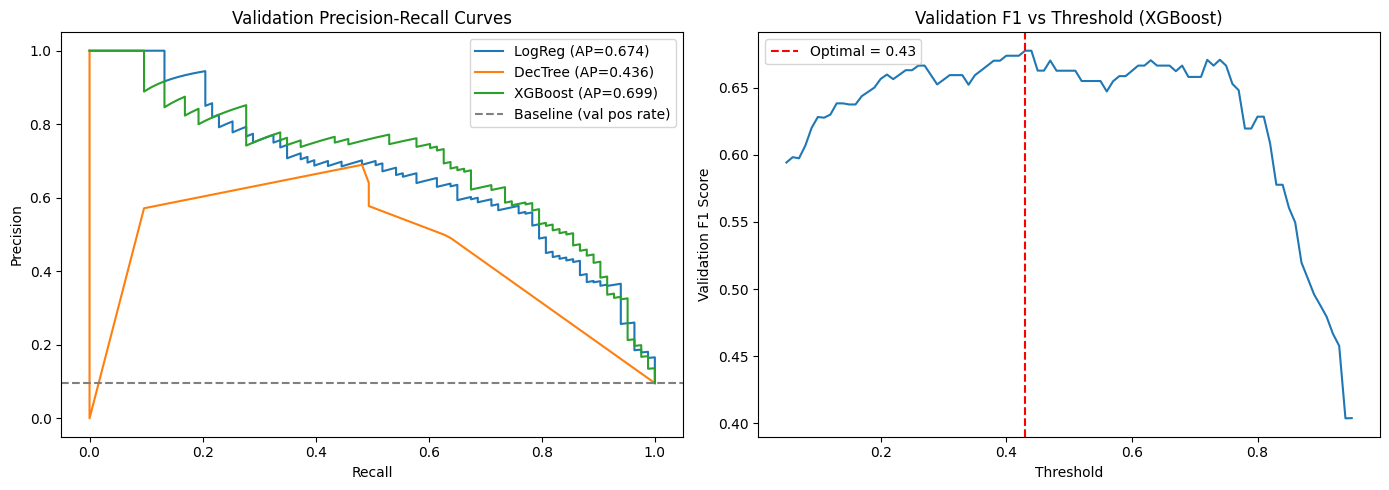

2026/03/31 07:41:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405610899105125.5.azuredatabricks.net/ml/experiments/3128321741550201/models/m-9e91dce0fa8941fc8cecbcabbb380bcd?o=7405610899105125



Final test metrics for XGBoost
  ROC-AUC: 0.9446
  Average Precision: 0.7382
  F1 @ 0.50: 0.6598
  F1 @ 0.43: 0.6667
  Test confusion matrix @ tuned threshold:
[[952  39]
 [ 27  66]]


In [0]:
import matplotlib.pyplot as plt

# ── Compare models on VALIDATION ──
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "XGBoost"],
    "Validation ROC-AUC": [lr_val_roc_auc, dt_val_roc_auc, xgb_val_roc_auc],
    "Validation AP": [lr_val_ap, dt_val_ap, xgb_val_ap],
    "Validation F1 (0.5 cutoff)": [lr_val_f1, dt_val_f1, xgb_val_f1],
})
print(results.to_string(index=False))

candidates = {
    "LogisticRegression": {
        "val_ap": lr_val_ap,
        "val_roc_auc": lr_val_roc_auc,
        "val_f1": lr_val_f1,
        "val_proba": lr_val_proba,
        "val_cm": lr_val_cm,
        "needs_scaling": True,
        "factory": lambda: LogisticRegression(
            max_iter=3000, random_state=42, solver="lbfgs",
            class_weight="balanced"
        ),
        "params": {
            "model_type": "LogisticRegression",
            "solver": "lbfgs",
            "max_iter": 3000,
            "class_weight": "balanced",
        },
    },
    "DecisionTree": {
        "val_ap": dt_val_ap,
        "val_roc_auc": dt_val_roc_auc,
        "val_f1": dt_val_f1,
        "val_proba": dt_val_proba,
        "val_cm": dt_val_cm,
        "needs_scaling": False,
        "factory": lambda: DecisionTreeClassifier(
            max_depth=10, random_state=42, class_weight="balanced"
        ),
        "params": {
            "model_type": "DecisionTree",
            "max_depth": 10,
            "class_weight": "balanced",
        },
    },
    "XGBoost": {
        "val_ap": xgb_val_ap,
        "val_roc_auc": xgb_val_roc_auc,
        "val_f1": xgb_val_f1,
        "val_proba": xgb_val_proba,
        "val_cm": xgb_val_cm,
        "needs_scaling": False,
        "factory": lambda: XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            random_state=42, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw,
            eval_metric="aucpr", tree_method="hist", n_jobs=-1
        ),
        "params": {
            "model_type": "XGBoost",
            "n_estimators": 300,
            "max_depth": 6,
            "learning_rate": 0.05,
            "scale_pos_weight": round(spw, 3),
        },
    },
}

best_name = max(candidates, key=lambda k: candidates[k]["val_ap"])
best_val_proba = candidates[best_name]["val_proba"]

print(f"\nBest model by validation AP: {best_name} "
      f"(AP = {candidates[best_name]['val_ap']:.4f})")

# ── Tune threshold on VALIDATION only ──
thresholds = np.arange(0.05, 0.96, 0.01)
val_f1_scores = []
for t in thresholds:
    preds_t = (best_val_proba >= t).astype(int)
    val_f1_scores.append(f1_score(y_val, preds_t, zero_division=0))

optimal_idx = int(np.argmax(val_f1_scores))
optimal_threshold = float(thresholds[optimal_idx])
optimal_val_f1 = float(val_f1_scores[optimal_idx])

print(f"Optimal validation threshold: {optimal_threshold:.2f}  →  "
      f"Validation F1: {optimal_val_f1:.4f}")

# ── Validation PR curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lr_rec, lr_prec, label=f"LogReg (AP={lr_val_ap:.3f})")
axes[0].plot(dt_rec, dt_prec, label=f"DecTree (AP={dt_val_ap:.3f})")
axes[0].plot(xgb_rec, xgb_prec, label=f"XGBoost (AP={xgb_val_ap:.3f})")
axes[0].axhline(y=y_val.mean(), color="gray", linestyle="--",
                label="Baseline (val pos rate)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Validation Precision-Recall Curves")
axes[0].legend()

axes[1].plot(thresholds, val_f1_scores)
axes[1].axvline(x=optimal_threshold, color="red", linestyle="--",
                label=f"Optimal = {optimal_threshold:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Validation F1 Score")
axes[1].set_title(f"Validation F1 vs Threshold ({best_name})")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Refit on FULL training data, evaluate ONCE on test ──
best_model = candidates[best_name]["factory"]()
needs_scaling = candidates[best_name]["needs_scaling"]

if needs_scaling:
    best_model.fit(X_train_scaled, y_train)
    best_proba = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    best_model.fit(X_train, y_train)
    best_proba = best_model.predict_proba(X_test)[:, 1]

best_pred_default = (best_proba >= 0.5).astype(int)
best_pred_tuned = (best_proba >= optimal_threshold).astype(int)

best_test_roc_auc = roc_auc_score(y_test, best_proba)
best_test_ap = average_precision_score(y_test, best_proba)
best_test_f1_default = f1_score(y_test, best_pred_default, zero_division=0)
best_test_f1 = f1_score(y_test, best_pred_tuned, zero_division=0)
best_test_cm_default = confusion_matrix(y_test, best_pred_default)
best_test_cm = confusion_matrix(y_test, best_pred_tuned)
best_prec, best_rec, _ = precision_recall_curve(y_test, best_proba)

with mlflow.start_run(run_name=f"{best_name.lower()}_final_fulltrain") as best_run:
    mlflow.log_params({
        **candidates[best_name]["params"],
        "n_features": X_train.shape[1],
        "unit_of_analysis": "provider",
        "split_strategy": "provider_level_stratified",
        "selection_metric": "validation_average_precision",
        "threshold_source": "validation_split",
        "optimal_threshold": optimal_threshold,
        "numeric_scaled": needs_scaling,
    })
    mlflow.log_metrics({
        "val_roc_auc": float(candidates[best_name]["val_roc_auc"]),
        "val_average_precision": float(candidates[best_name]["val_ap"]),
        "val_f1_default_0.5": float(candidates[best_name]["val_f1"]),
        "val_f1_tuned": float(optimal_val_f1),
        "test_roc_auc": float(best_test_roc_auc),
        "test_average_precision": float(best_test_ap),
        "test_f1_default_0.5": float(best_test_f1_default),
        "test_f1_tuned": float(best_test_f1),
    })
    mlflow.sklearn.log_model(best_model, "model", input_example=X_train.iloc[:5])
    mlflow.log_dict(
        {"test_confusion_matrix_tuned": best_test_cm.tolist()},
        "test_confusion_matrix_tuned.json"
    )
    best_run_id = best_run.info.run_id

print(f"\nFinal test metrics for {best_name}")
print(f"  ROC-AUC: {best_test_roc_auc:.4f}")
print(f"  Average Precision: {best_test_ap:.4f}")
print(f"  F1 @ 0.50: {best_test_f1_default:.4f}")
print(f"  F1 @ {optimal_threshold:.2f}: {best_test_f1:.4f}")
print(f"  Test confusion matrix @ tuned threshold:\n{best_test_cm}")

## 10. SHAP Values

SHAP already has base_score fix or different code path — no patch needed
Top 15 SHAP Features:
               feature  mean_abs_shap
         TotalClaimAmt       1.988502
                MaxLOS       1.273985
  ClaimsPerBeneficiary       0.746480
           MaxClaimAmt       0.331761
         AvgDeductible       0.298833
           StdClaimAmt       0.266704
            ClaimCount       0.245271
      RenalDiseaseRate       0.205569
      HeartfailureRate       0.183874
   DeceasedPatientRate       0.179808
     AvgPhysicianCount       0.169333
            CancerRate       0.165094
      OsteoporasiaRate       0.163051
OperatingPhysicianRate       0.152677
         AlzheimerRate       0.152560


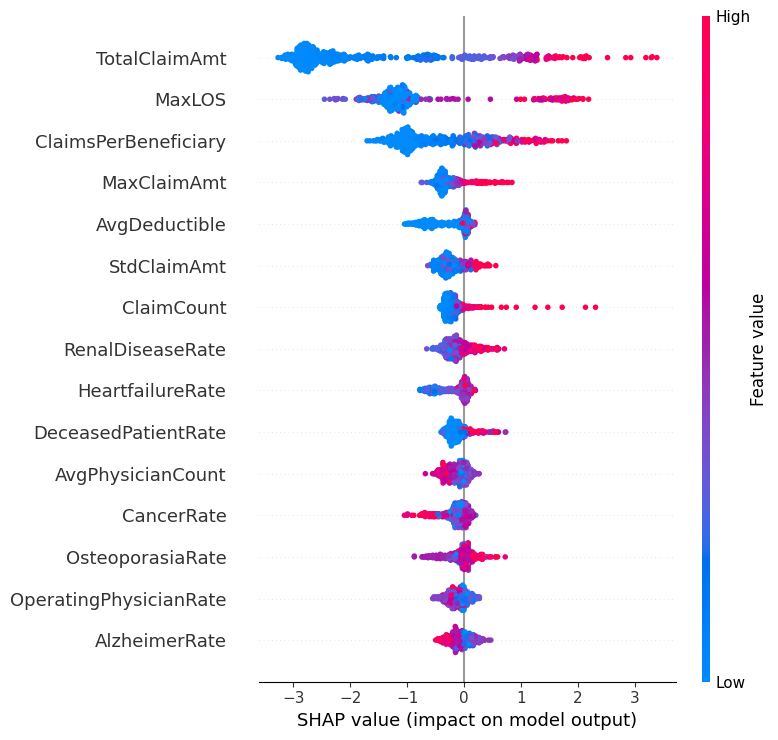

In [0]:
# ── Patch SHAP for XGBoost >= 3.1 base_score bug ──
# Databricks SHAP version does: float(learner_model_param["base_score"])
# XGBoost >= 3.1 stores it as '[5.0027084E-1]' which can't be cast to float.
# We patch the installed SHAP file directly before importing TreeExplainer.

import re as _re

_shap_tree_path = shap.explainers._tree.__file__

with open(_shap_tree_path, "r") as _f:
    _shap_src = _f.read()

# Only patch if the old broken pattern exists (no ast.literal_eval guard)
if 'self.base_score = float(learner_model_param["base_score"])' in _shap_src:
    _patched = _shap_src.replace(
        'self.base_score = float(learner_model_param["base_score"])',
        '_bs = learner_model_param["base_score"]\n'
        '        if isinstance(_bs, str):\n'
        '            _bs = _bs.strip("[]")\n'
        '        self.base_score = float(_bs)'
    )
    with open(_shap_tree_path, "w") as _f:
        _f.write(_patched)

    # Force Python to reload the patched module
    import importlib
    importlib.reload(shap.explainers._tree)
    importlib.reload(shap.explainers)
    importlib.reload(shap)
    print("SHAP patched: base_score bracket fix applied")
else:
    print("SHAP already has base_score fix or different code path — no patch needed")

# ── Background sample ──
background_sample = X_train.sample(
    n=min(100, len(X_train)), random_state=42)

# ── Explainer selection based on model type ──
if best_name in ("DecisionTree", "XGBoost"):
    explainer = shap.TreeExplainer(best_model)
elif best_name == "LogisticRegression":
    bg_scaled = scaler_full.transform(background_sample)
    explainer = shap.LinearExplainer(best_model, masker=bg_scaled)

# ── Compute SHAP on test set ──
shap_sample_size = min(500, len(X_test))

if needs_scaling:
    X_shap = pd.DataFrame(
        X_test_scaled[:shap_sample_size],
        columns=FEATURE_COLS
    )
else:
    X_shap = X_test.iloc[:shap_sample_size]

shap_values = explainer.shap_values(X_shap)

# For binary classifiers, shap_values may be [class_0_array, class_1_array]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ── Global feature importance ──
shap_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 SHAP Features:")
print(shap_importance.head(15).to_string(index=False))

# ── Summary plot ──
shap.summary_plot(shap_values, X_shap, max_display=15, show=True)

## 11. Log Artifacts & Register Model

In [0]:
with mlflow.start_run(run_id=best_run_id):

    # ── Background sample for SHAP at inference ──
    background_sample.to_parquet("/tmp/shap_background.parquet", index=False)
    mlflow.log_artifact("/tmp/shap_background.parquet")

    # ── Feature column order (critical for Day 4 alignment) ──
    with open("/tmp/feature_columns.json", "w") as f:
        json.dump(FEATURE_COLS, f)
    mlflow.log_artifact("/tmp/feature_columns.json")

    # ── SHAP importance table ──
    shap_importance.to_csv("/tmp/shap_feature_importance.csv", index=False)
    mlflow.log_artifact("/tmp/shap_feature_importance.csv")

    # ── Scaler (needed for LogReg at inference) ──
    if needs_scaling:
        import pickle
        with open("/tmp/scaler.pkl", "wb") as f:
            pickle.dump(scaler_full, f)
        mlflow.log_artifact("/tmp/scaler.pkl")

print("Artifacts logged: shap_background.parquet, feature_columns.json, "
      "shap_feature_importance.csv"
      + (", scaler.pkl" if needs_scaling else ""))

# ── Register best model ──
model_uri = f"runs:/{best_run_id}/model"
registered = mlflow.register_model(model_uri, "denial-risk-model")
print(f"\nRegistered model: {registered.name}  |  version: {registered.version}")

Artifacts logged: shap_background.parquet, feature_columns.json, shap_feature_importance.csv


Registered model 'denial-risk-model' already exists. Creating a new version of this model...
2026/03/31 07:41:17 WARNING mlflow.tracking._model_registry.fluent: Run with id ecaad668cb56438b8ce36ad4e08ebf7b has no artifacts at artifact path 'model', registering model based on models:/m-9e91dce0fa8941fc8cecbcabbb380bcd instead


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '1' of model 'capstone.default.denial-risk-model': https://adb-7405610899105125.5.azuredatabricks.net/explore/data/models/capstone/default/denial-risk-model/version/1?o=7405610899105125



Registered model: capstone.default.denial-risk-model  |  version: 1


## 12. Save Provider Lookup Table

This table provides the provider-level aggregation function at inference time.
For a new provider, Day 4 aggregates their claims using the same logic as
`aggregate_to_provider()` and feeds the resulting feature row into the model.

In [0]:
# The training provider aggregates serve as the lookup for known providers
# For unknown providers at inference, aggregate their claims on the fly

provider_lookup = train_providers_df.select(
    "Provider",
    *[c for c in FEATURE_COLS if c in train_providers_df.columns]
)

provider_lookup.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("capstone.bronze.provider_lookup")

provider_lookup.toPandas().to_parquet(
    "/tmp/provider_lookup_table.parquet", index=False)
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact("/tmp/provider_lookup_table.parquet")

print(f"Provider lookup saved: {provider_lookup.count():,} providers")
provider_lookup.show(5)

Provider lookup saved: 4,326 providers
+--------+----------+----------------------+----------------+--------------------+------------------+------------------+-----------+-------------+------------------+------------------+-------------------+------+---------------------+---------------------+---------------------+---------------------+------------------+-------------------+--------------------+-------------------+----------------------+-------------------+--------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-----------------+-------------------+------------------+
|Provider|ClaimCount|UniqueBeneficiaryCount|UniqueClaimCount|ClaimsPerBeneficiary|       AvgClaimAmt|       StdClaimAmt|MaxClaimAmt|TotalClaimAmt|     AvgDeductible|  AvgClaimDuration|             AvgLOS|MaxLOS|AvgDiagnosis

## 13. Summary

In [0]:
print("=" * 65)
print("DAY 3 — ML MODELING COMPLETE (FIXED)")
print("=" * 65)
print(f"Unit of analysis:           PROVIDER (not claim)")
print(f"Best model:                 {best_name}")
print(f"Validation AP:              {candidates[best_name]['val_ap']:.4f}")
print(f"Validation ROC-AUC:         {candidates[best_name]['val_roc_auc']:.4f}")
print(f"Validation F1 (default):    {candidates[best_name]['val_f1']:.4f}")
print(f"Optimal threshold (val):    {optimal_threshold:.2f}")
print(f"Test ROC-AUC:               {best_test_roc_auc:.4f}")
print(f"Test Average Precision:     {best_test_ap:.4f}")
print(f"Test F1 (default 0.5):      {best_test_f1_default:.4f}")
print(f"Test F1 (tuned):            {best_test_f1:.4f}")
print(f"MLflow run ID:              {best_run_id}")
print(f"Registered model:           denial-risk-model v{registered.version}")
print(f"Features used:              {len(FEATURE_COLS)}")
print(f"Train providers:            {len(X_train):,}")
print(f"Test providers:             {len(X_test):,}")
print("-" * 65)
print("Artifacts logged to MLflow:")
print("  • shap_background.parquet")
print("  • feature_columns.json")
print("  • shap_feature_importance.csv")
if needs_scaling:
    print("  • scaler.pkl")
print("  • provider_lookup_table.parquet")
print("-" * 65)
print("\nReady for Day 4 — LLM Orchestrator Layer")

DAY 3 — ML MODELING COMPLETE (FIXED)
Unit of analysis:           PROVIDER (not claim)
Best model:                 XGBoost
Validation AP:              0.6993
Validation ROC-AUC:         0.9427
Validation F1 (default):    0.6629
Optimal threshold (val):    0.43
Test ROC-AUC:               0.9446
Test Average Precision:     0.7382
Test F1 (default 0.5):      0.6598
Test F1 (tuned):            0.6667
MLflow run ID:              ecaad668cb56438b8ce36ad4e08ebf7b
Registered model:           denial-risk-model v1
Features used:              38
Train providers:            4,326
Test providers:             1,084
-----------------------------------------------------------------
Artifacts logged to MLflow:
  • shap_background.parquet
  • feature_columns.json
  • shap_feature_importance.csv
  • provider_lookup_table.parquet
-----------------------------------------------------------------

Ready for Day 4 — LLM Orchestrator Layer
